In [1]:
!pip install wilds matplotlib torch torchvision terratorch umap-learn seaborn scikit-learn matplotlib

  Using cached terratorch-1.2.7-py3-none-any.whl.metadata (13 kB)
  Using cached umap_learn-0.5.12-py3-none-any.whl.metadata (24 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached rioxarray-0.22.0-py3-none-any.whl.metadata (5.4 kB)
  Using cached albumentations-2.0.8-py3-none-any.whl.metadata (43 kB)
  Using cached albucore-0.1.6-py3-none-any.whl.metadata (15 kB)
  Using cached rasterio-1.5.0-cp314-cp314-win_amd64.whl.metadata (8.9 kB)
  Using cached torchmetrics-1.9.0-py3-none-any.whl.metadata (23 kB)
  Using cached geopandas-1.1.3-py3-none-any.whl.metadata (2.3 kB)
  Using cached lightly-1.5.22-py3-none-any.whl.metadata (38 kB)
  Using cached h5py-3.16.0-cp314-cp314-win_amd64.whl.metadata (3.1 kB)
  Using cached lightning-2.6.1-py3-none-any.whl.metadata (44 kB)
  Using cached segmentation_models_pytorch-0.5.0-py3-none-any.whl.metadata (17 kB)
  Using cached jsonargparse-4.48.0-py3-none-any.whl.metadata (12 kB)
  Using cached torchgeo-0.9.0-py3-none-an

  error: subprocess-exited-with-error
  
  × Building wheel for stringzilla (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [10 lines of output]
      running bdist_wheel
      running build
      running build_py
      creating build\lib.win-amd64-cpython-314\cli
      copying cli\split.py -> build\lib.win-amd64-cpython-314\cli
      copying cli\wc.py -> build\lib.win-amd64-cpython-314\cli
      copying cli\__init__.py -> build\lib.win-amd64-cpython-314\cli
      running build_ext
      building 'stringzilla' extension
      error: Microsoft Visual C++ 14.0 or greater is required. Get it with "Microsoft C++ Build Tools": https://visualstudio.microsoft.com/visual-cpp-build-tools/
      [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for stringzilla

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip
error: fa

In [2]:
import ClusteringPipeline
import Student
# ---------------------------------------------------------
#  Simplified DataLoader
# ---------------------------------------------------------
import torch
from pathlib import Path
from PIL import Image
import torchvision.transforms as T

def get_input(idx):
    """
    Returns an RGB image for a given idx, ensuring file handles are safely closed.
    """
    file_path = Path('./data/' + 'fmow_v1.1') / 'images' / f'rgb_img_{idx}.png'
    # The 'with' block guarantees the file on disk is closed the microsecond we are done
    with Image.open(file_path) as img:
        # .convert() creates the standalone memory object we need
        return img.convert('RGB')

preprocessImagenet = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])


C:\Users\kevin\PycharmProjects\master_thesis\.venv\Lib\site-packages\outdated\__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [3]:
import FoundationModel
pipeline = ClusteringPipeline.ClusteringPipeline()
FM = FoundationModel.FoundationModel()

# Assuming you've updated sample_dataset to just take the top 15 classes if no specific list is given:
df_full = pipeline.get_dataset()
df_sample = pipeline.sample_dataset(df_full, samples_per_class=200) # Ensure 15 distinct classes are kept

# 2. Extract Embeddings
df_base = pipeline.get_embeddings(df_sample, FM, get_input, preprocessImagenet, save_path="./dino",compute_stats=False)

class_to_concept_mapping = {
    # Concept 1
    "stadium": 1,
    "swimming_pool": 1,
    "multi-unit_residential": 1,
    "recreational_facility": 1,
    "park": 1,

    # Concept 2
    "airport_hangar": 2,
    "airport_terminal": 2,
    "crop_field": 2,
    "amusement_park": 2,
    "military_facility": 2,

    # Concept 3
    "nuclear_powerplant": 3,
    "airport": 3,
    "runway": 3,
    "aquaculture": 3,
    "wind_farm": 3
}

# Apply it to your dataframe
df_base = pipeline.create_concepts(df_base, class_to_concept_mapping)
# 4. PRE-SHUFFLE ONCE WITH A FIXED SEED.
# This guarantees every grid search config sees the exact same sequence.
df_stream = df_base.sample(frac=1, random_state=42).reset_index(drop=True)
# 5. ORDER BY CONCEPT
df_stream = df_stream.sort_values(by='concept').reset_index(drop=True)

embedding_dim_base = len(df_stream['embedding'].iloc[0])

C:\Users\kevin\PycharmProjects\master_thesis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using cache found in C:\Users\kevin/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\kevin/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\kevin/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\kevin/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


--- Sampling 200 images per class ---
Found saved dataset at ./dino. Loading from disk...
Distribution of images across the new macro-classes:
concept
3    1000
2    1000
1    1000
Name: count, dtype: int64


In [4]:
#this will be filled with the printed output statistics of get_embeddings
preprocessFMOW = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.4279618263244629, 0.4296368956565857, 0.39697331190109253],
                         std =[0.25068026781082153, 0.2403821349143982, 0.2443935126066208]),
])

In [5]:
total_classes = len(df_stream['category'].unique())


Starting Experiment Suite: 0b_NoPretrain_LogSumDistillation

--- Running Config 1/1: {'batch_size': 25, 'distill_weight': 0.1, 'epochs_per_batch': 1, 'lr': 0.001} ---


C:\Users\kevin\PycharmProjects\master_thesis\.venv\Lib\site-packages\torchvision\models\_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
Stream:   0%|          | 0/3000 [00:00<?, ?it/s]


--- DRIFT DETECTED: Transitioning from Concept 0 to Concept 1 ---
Resetting accuracy metrics...


Stream:   1%|          | 35/3000 [00:01<02:00, 24.69it/s]

Loss output student: 2.5973
Loss distillation: 14.4980
Sample visti: 25 | Classi corrette: 0 | Accuratezza Cumulata: 0.00%


...

Loss output student: 2.8087
Loss distillation: 13.5172
Sample visti: 950 | Classi corrette: 12 | Accuratezza Cumulata: 1.26%


Stream: 100%|█████████▉| 2986/3000 [01:57<00:00, 26.01it/s]

Loss output student: 2.7298
Loss distillation: 13.4384
Sample visti: 975 | Classi corrette: 12 | Accuratezza Cumulata: 1.23%


Stream: 100%|██████████| 3000/3000 [01:58<00:00, 25.38it/s]

Loss output student: 2.8442
Loss distillation: 13.6677
Sample visti: 1000 | Classi corrette: 12 | Accuratezza Cumulata: 1.20%

--- Fine Stream | Accuratezza Finale: 1.20% ---

Plotting results for 0b_NoPretrain_LogSumDistillation...


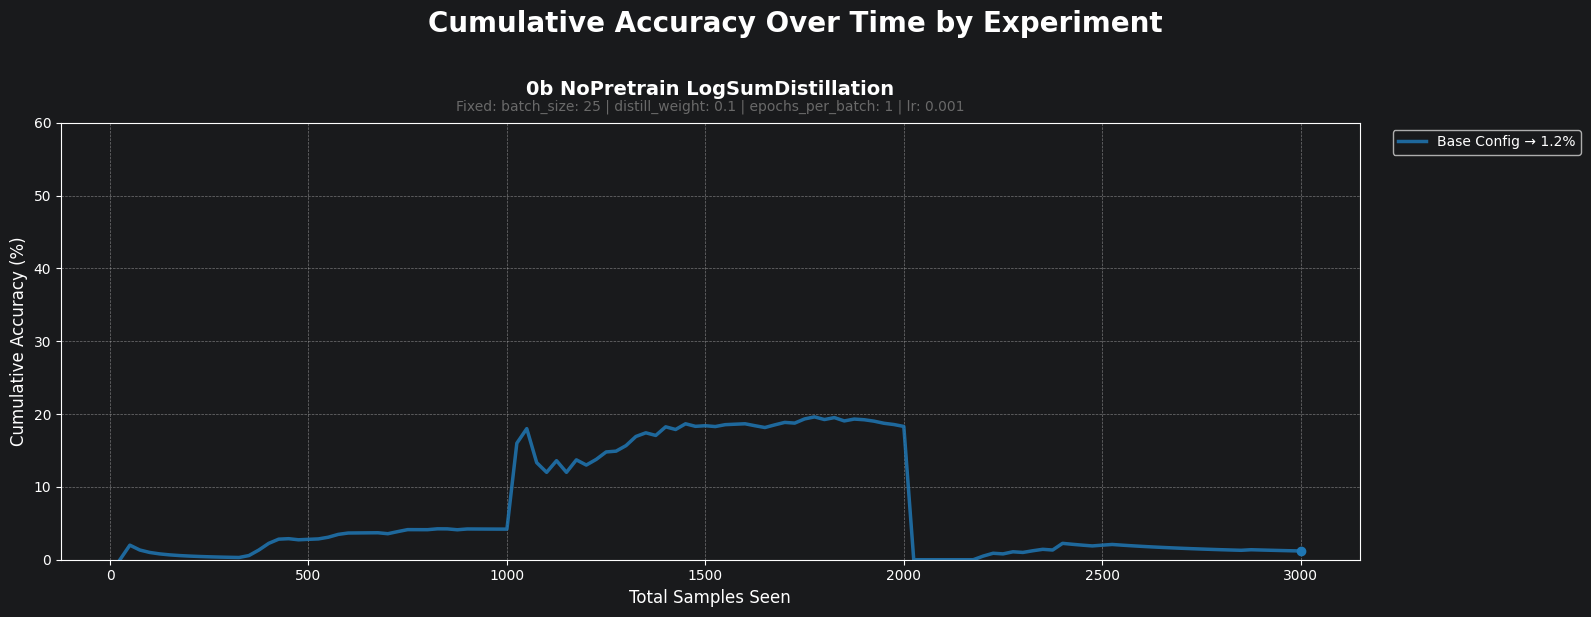

C:\Users\kevin\PycharmProjects\master_thesis\.venv\Lib\site-packages\torchvision\models\_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(



Starting Experiment Suite: 0a_NoPretrain_NoDistillation

--- Running Config 1/1: {'batch_size': 25, 'epochs_per_batch': 1, 'lr': 0.001} ---


Stream:   0%|          | 0/3000 [00:00<?, ?it/s]


--- DRIFT DETECTED: Transitioning from Concept 0 to Concept 1 ---
Resetting accuracy metrics...


Stream:   1%|          | 34/3000 [00:01<01:47, 27.55it/s]

...

Loss output student: 1.6831
Sample visti: 950 | Classi corrette: 133 | Accuratezza Cumulata: 14.00%


Stream:  99%|█████████▉| 2981/3000 [01:57<00:00, 21.46it/s]

Loss output student: 1.3844
Sample visti: 975 | Classi corrette: 142 | Accuratezza Cumulata: 14.56%


Stream: 100%|██████████| 3000/3000 [01:58<00:00, 25.33it/s]

Loss output student: 1.3947
Sample visti: 1000 | Classi corrette: 153 | Accuratezza Cumulata: 15.30%

--- Fine Stream | Accuratezza Finale: 15.30% ---

Plotting results for 0a_NoPretrain_NoDistillation...


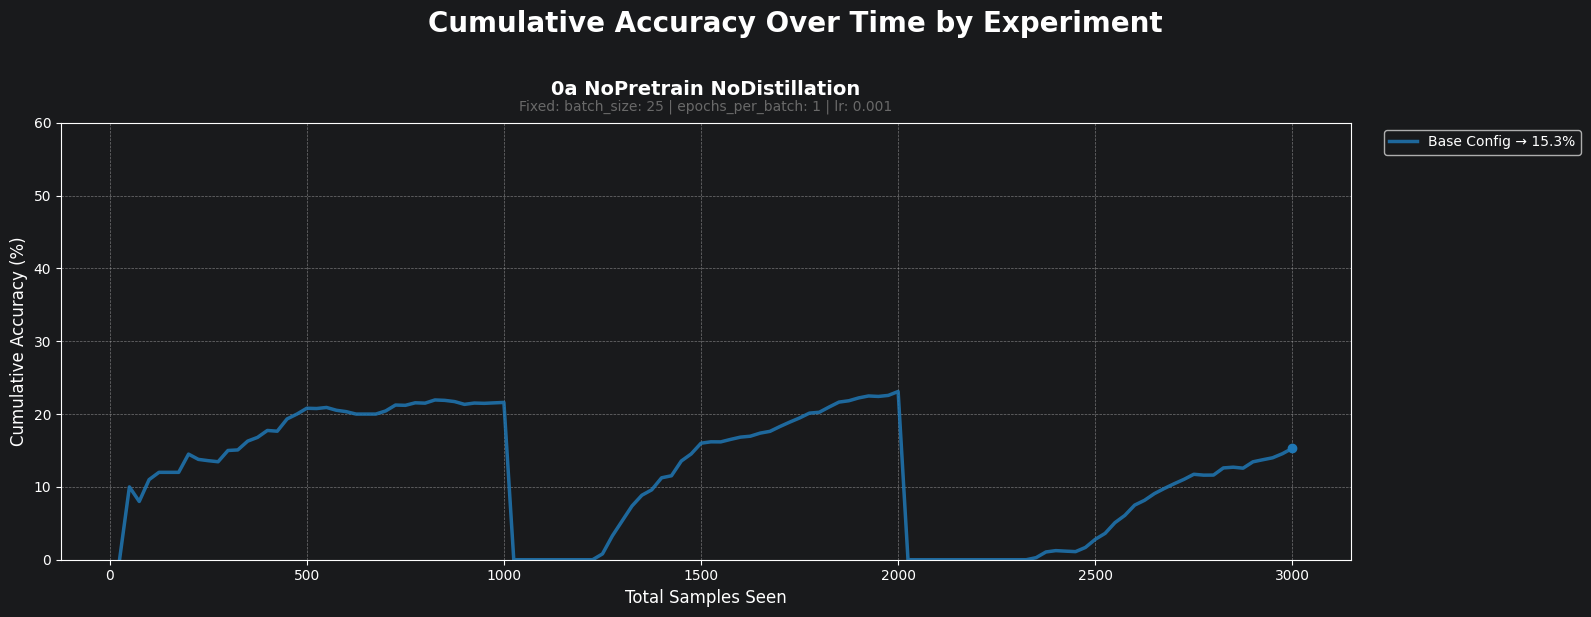

C:\Users\kevin\PycharmProjects\master_thesis\.venv\Lib\site-packages\torchvision\models\_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(



Starting Experiment Suite: 0c_NoPretrain_LinearDistillation

--- Running Config 1/1: {'batch_size': 25, 'distill_weight': 1, 'epochs_per_batch': 1, 'lr': 0.001} ---


Stream:   0%|          | 0/3000 [00:00<?, ?it/s]


--- DRIFT DETECTED: Transitioning from Concept 0 to Concept 1 ---
Resetting accuracy metrics...


Stream:   1%|          | 34/3000 [00:01<01:47, 27.70it/s]

...

Loss output student: 2.7510
Loss distillation: 0.8292
Sample visti: 950 | Classi corrette: 0 | Accuratezza Cumulata: 0.00%


Stream: 100%|█████████▉| 2985/3000 [02:08<00:00, 21.24it/s]

Loss output student: 2.7617
Loss distillation: 0.9614
Sample visti: 975 | Classi corrette: 0 | Accuratezza Cumulata: 0.00%


Stream: 100%|██████████| 3000/3000 [02:09<00:00, 23.13it/s]

Loss output student: 2.7468
Loss distillation: 0.8224
Sample visti: 1000 | Classi corrette: 0 | Accuratezza Cumulata: 0.00%

--- Fine Stream | Accuratezza Finale: 0.00% ---

Plotting results for 0c_NoPretrain_LinearDistillation...


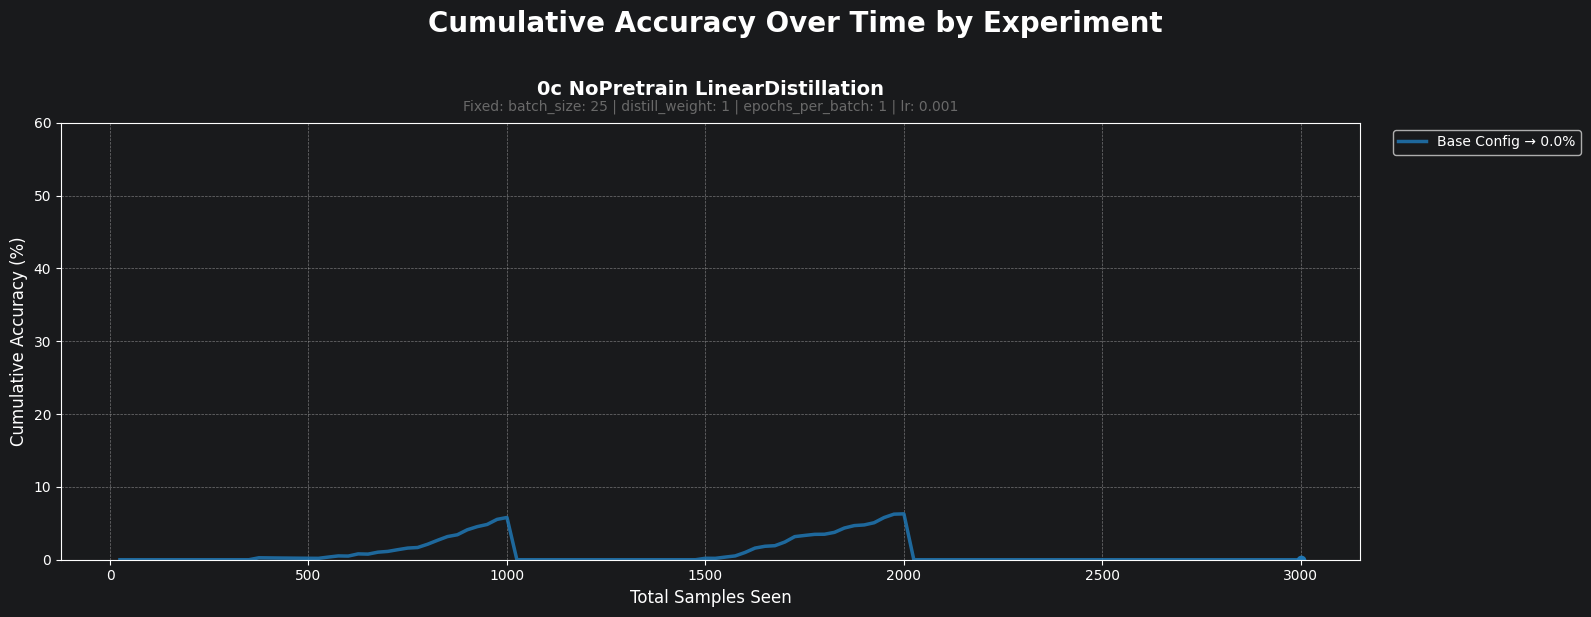

C:\Users\kevin\PycharmProjects\master_thesis\.venv\Lib\site-packages\torchvision\models\_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(



Starting Experiment Suite: 0d_NoPretrain_MLPDistillation

--- Running Config 1/1: {'batch_size': 25, 'distill_weight': 1, 'epochs_per_batch': 1, 'hidden_dim': 256, 'lr': 0.001} ---


Stream:   0%|          | 0/3000 [00:00<?, ?it/s]


--- DRIFT DETECTED: Transitioning from Concept 0 to Concept 1 ---
Resetting accuracy metrics...


Stream:   1%|          | 34/3000 [00:01<02:08, 23.11it/s]

...

Loss output student: 2.8200
Loss distillation: 0.8210
Sample visti: 950 | Classi corrette: 9 | Accuratezza Cumulata: 0.95%


Stream:  99%|█████████▉| 2982/3000 [02:15<00:00, 20.77it/s]

Loss output student: 2.7881
Loss distillation: 0.9547
Sample visti: 975 | Classi corrette: 9 | Accuratezza Cumulata: 0.92%


Stream: 100%|██████████| 3000/3000 [02:16<00:00, 22.04it/s]

Loss output student: 2.7515
Loss distillation: 0.8132
Sample visti: 1000 | Classi corrette: 10 | Accuratezza Cumulata: 1.00%

--- Fine Stream | Accuratezza Finale: 1.00% ---

Plotting results for 0d_NoPretrain_MLPDistillation...


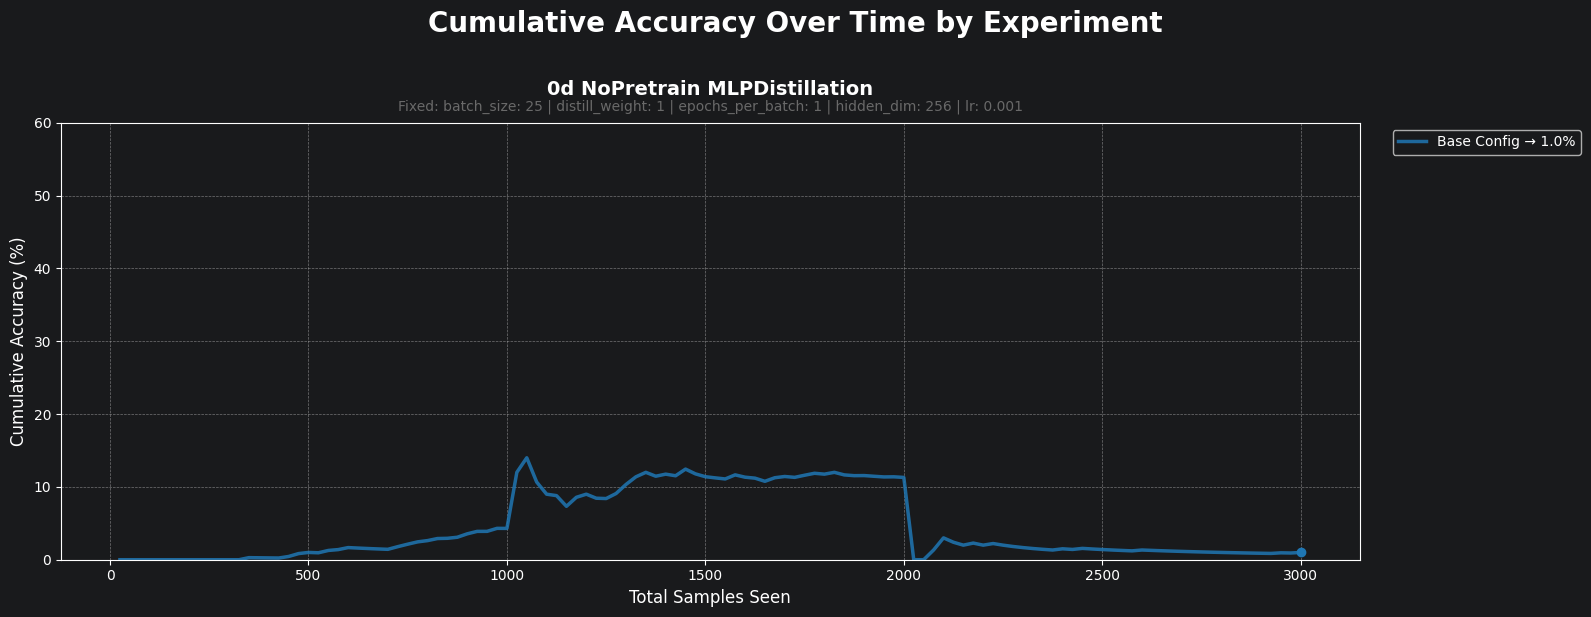

C:\Users\kevin\PycharmProjects\master_thesis\.venv\Lib\site-packages\torchvision\models\_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(



Starting Experiment Suite: 2_Pretrained_LogSumDistillation

--- Running Config 1/1: {'batch_size': 25, 'distill_weight': 0.1, 'epochs_per_batch': 1, 'lr': 0.001} ---


Stream:   0%|          | 0/3000 [00:00<?, ?it/s]


--- DRIFT DETECTED: Transitioning from Concept 0 to Concept 1 ---
Resetting accuracy metrics...


Stream:   1%|          | 32/3000 [00:01<02:04, 23.93it/s]

...

Loss output student: 3.0668
Loss distillation: 13.7272
Sample visti: 950 | Classi corrette: 0 | Accuratezza Cumulata: 0.00%


Stream:  99%|█████████▉| 2982/3000 [02:15<00:00, 22.18it/s]

Loss output student: 2.8604
Loss distillation: 13.5723
Sample visti: 975 | Classi corrette: 0 | Accuratezza Cumulata: 0.00%


Stream: 100%|██████████| 3000/3000 [02:17<00:00, 21.88it/s]

Loss output student: 2.8766
Loss distillation: 13.5079
Sample visti: 1000 | Classi corrette: 0 | Accuratezza Cumulata: 0.00%

--- Fine Stream | Accuratezza Finale: 0.00% ---

Plotting results for 2_Pretrained_LogSumDistillation...


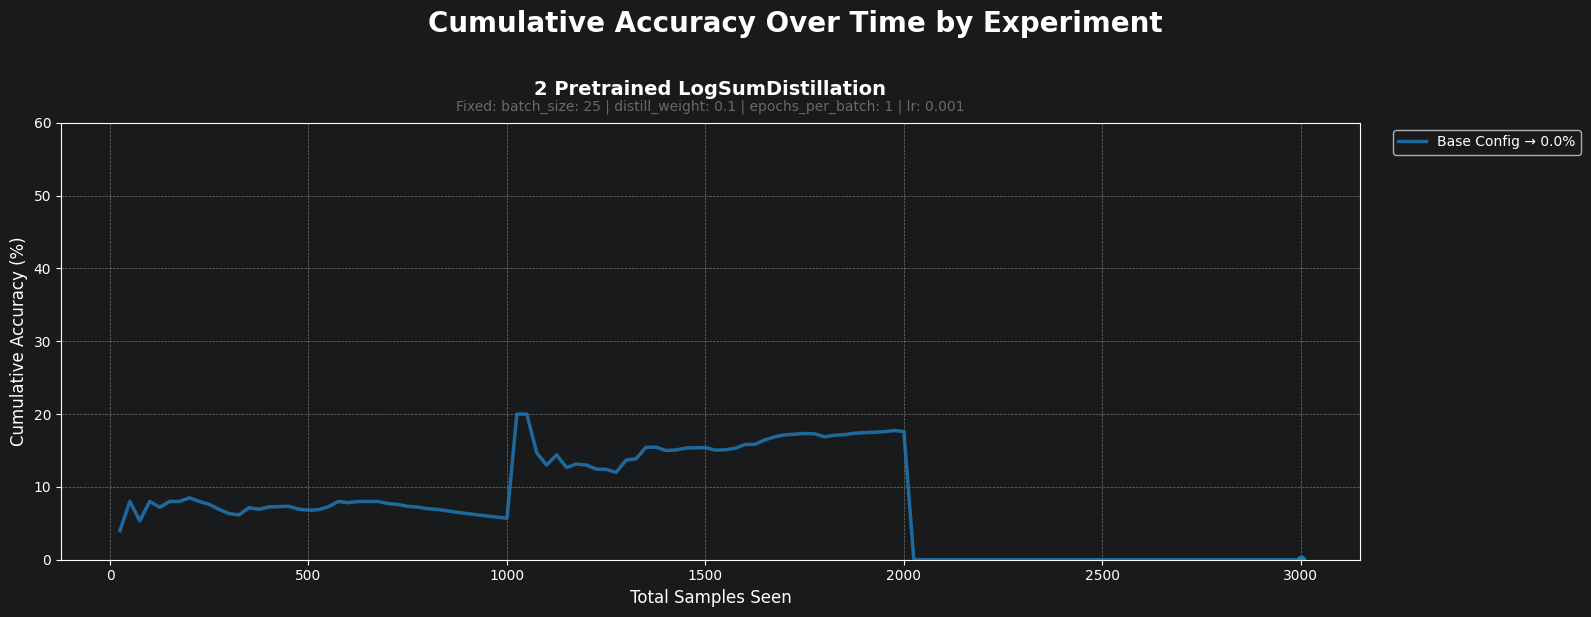

C:\Users\kevin\PycharmProjects\master_thesis\.venv\Lib\site-packages\torchvision\models\_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(



Starting Experiment Suite: 1_Pretrained_NoDistillation

--- Running Config 1/1: {'batch_size': 25, 'epochs_per_batch': 1, 'lr': 0.001} ---


Stream:   0%|          | 0/3000 [00:00<?, ?it/s]


--- DRIFT DETECTED: Transitioning from Concept 0 to Concept 1 ---
Resetting accuracy metrics...


Stream:   1%|          | 33/3000 [00:01<02:06, 23.49it/s]

...

Loss output student: 1.6725
Sample visti: 950 | Classi corrette: 136 | Accuratezza Cumulata: 14.32%


Stream: 100%|█████████▉| 2985/3000 [02:17<00:00, 20.90it/s]

Loss output student: 1.3056
Sample visti: 975 | Classi corrette: 143 | Accuratezza Cumulata: 14.67%


Stream: 100%|██████████| 3000/3000 [02:17<00:00, 21.74it/s]

Loss output student: 1.4909
Sample visti: 1000 | Classi corrette: 149 | Accuratezza Cumulata: 14.90%

--- Fine Stream | Accuratezza Finale: 14.90% ---

Plotting results for 1_Pretrained_NoDistillation...


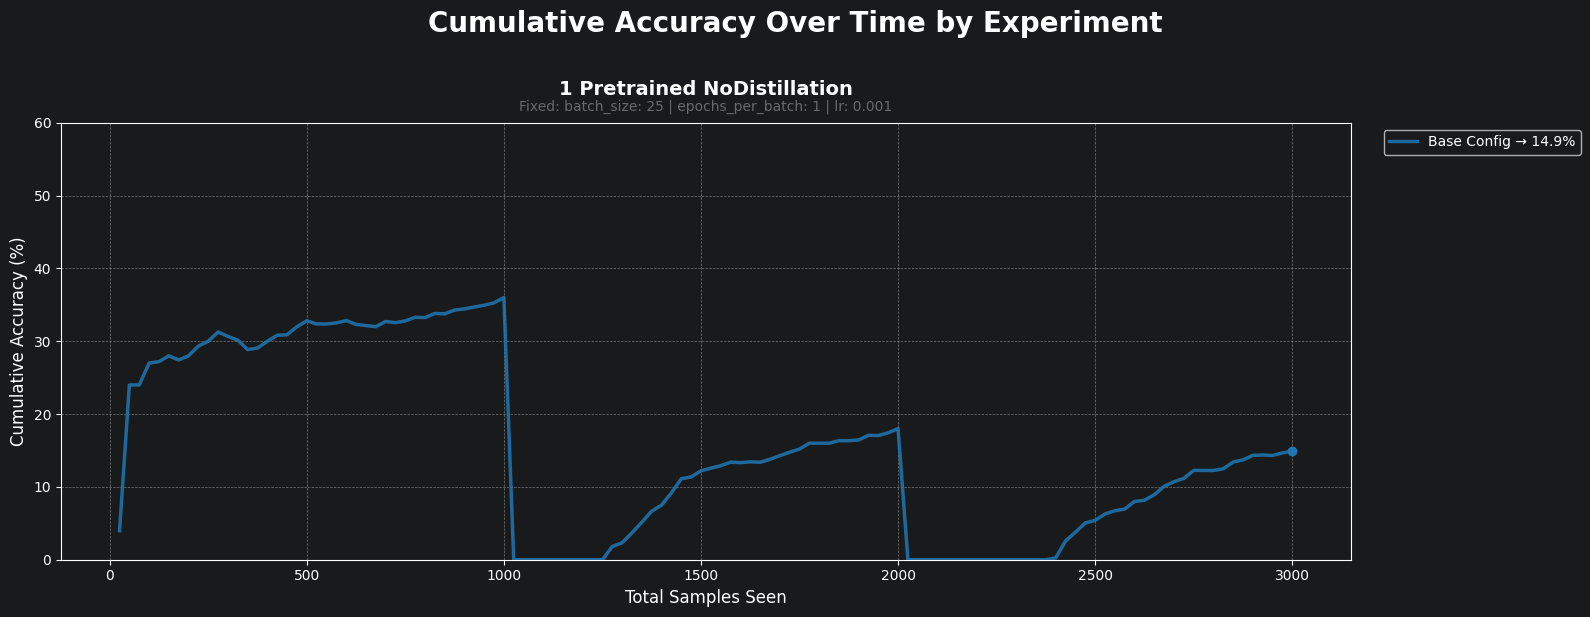

C:\Users\kevin\PycharmProjects\master_thesis\.venv\Lib\site-packages\torchvision\models\_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(



Starting Experiment Suite: 3_Pretrained_LinearDistillation

--- Running Config 1/1: {'batch_size': 25, 'distill_weight': 1, 'epochs_per_batch': 1, 'lr': 0.001} ---


Stream:   0%|          | 0/3000 [00:00<?, ?it/s]


--- DRIFT DETECTED: Transitioning from Concept 0 to Concept 1 ---
Resetting accuracy metrics...


Stream:   1%|          | 35/3000 [00:01<01:55, 25.65it/s]

...

Loss output student: 2.7721
Loss distillation: 0.8750
Sample visti: 950 | Classi corrette: 0 | Accuratezza Cumulata: 0.00%


Stream:  99%|█████████▉| 2984/3000 [02:17<00:00, 19.49it/s]

Loss output student: 2.7455
Loss distillation: 0.9806
Sample visti: 975 | Classi corrette: 0 | Accuratezza Cumulata: 0.00%


Stream: 100%|██████████| 3000/3000 [02:18<00:00, 21.64it/s]

Loss output student: 2.7451
Loss distillation: 0.8506
Sample visti: 1000 | Classi corrette: 0 | Accuratezza Cumulata: 0.00%

--- Fine Stream | Accuratezza Finale: 0.00% ---

Plotting results for 3_Pretrained_LinearDistillation...


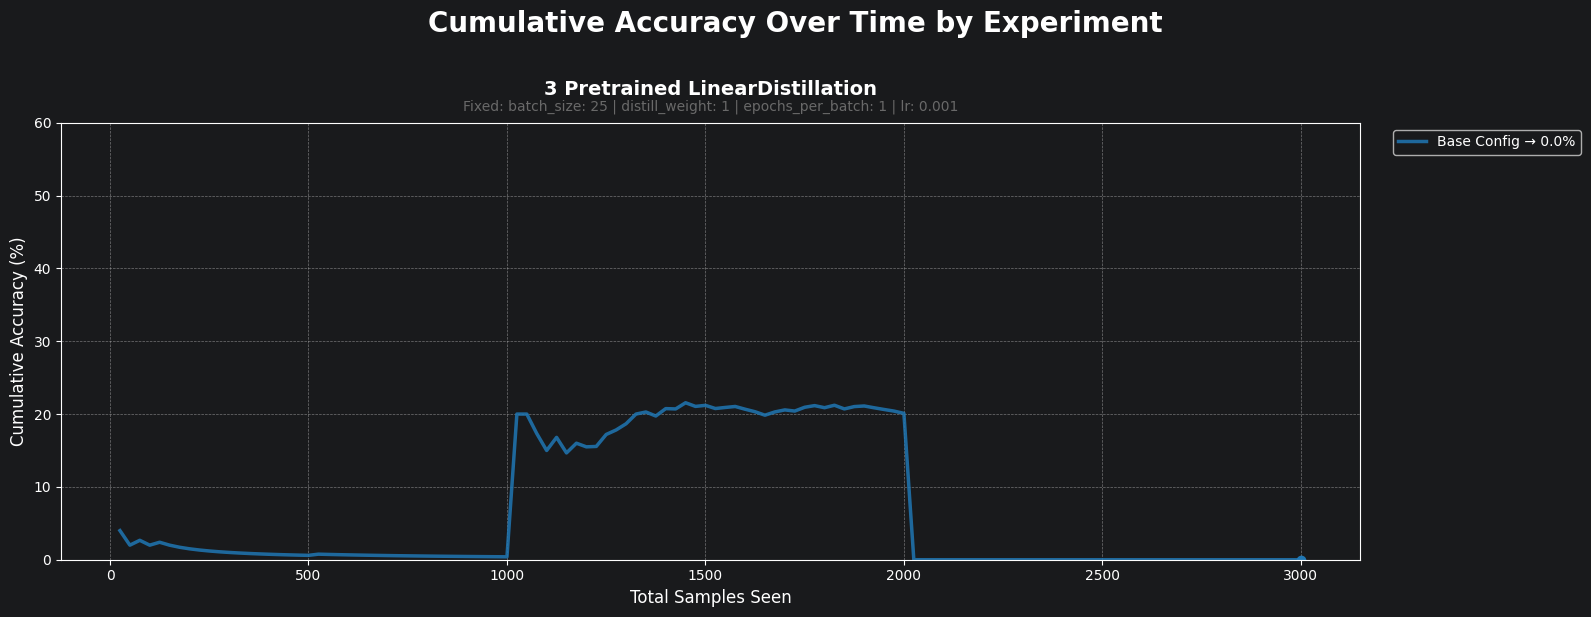

C:\Users\kevin\PycharmProjects\master_thesis\.venv\Lib\site-packages\torchvision\models\_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(



Starting Experiment Suite: 4_Pretrained_MLPDistillation

--- Running Config 1/1: {'batch_size': 25, 'distill_weight': 1, 'epochs_per_batch': 1, 'hidden_dim': 256, 'lr': 0.001} ---


Stream:   0%|          | 0/3000 [00:00<?, ?it/s]


--- DRIFT DETECTED: Transitioning from Concept 0 to Concept 1 ---
Resetting accuracy metrics...


Stream:   1%|          | 34/3000 [00:01<01:59, 24.75it/s]

...

Loss output student: 2.8379
Loss distillation: 0.8189
Sample visti: 950 | Classi corrette: 0 | Accuratezza Cumulata: 0.00%


Stream:  99%|█████████▉| 2982/3000 [02:18<00:00, 21.88it/s]

Loss output student: 2.8300
Loss distillation: 0.9512
Sample visti: 975 | Classi corrette: 0 | Accuratezza Cumulata: 0.00%


Stream: 100%|██████████| 3000/3000 [02:19<00:00, 21.52it/s]

Loss output student: 2.8502
Loss distillation: 0.8119
Sample visti: 1000 | Classi corrette: 0 | Accuratezza Cumulata: 0.00%

--- Fine Stream | Accuratezza Finale: 0.00% ---

Plotting results for 4_Pretrained_MLPDistillation...


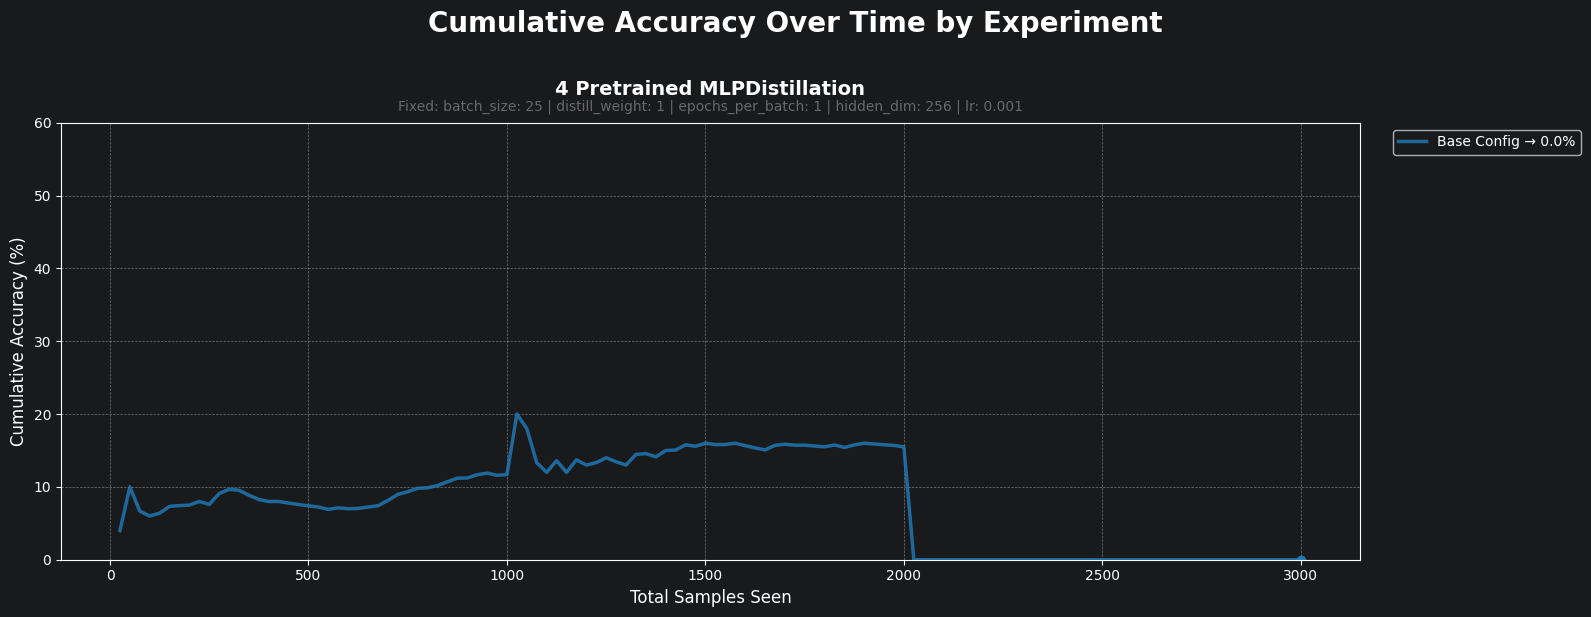


Starting Experiment Suite: 6_Linear_Probing_UB

--- Running Config 1/1: {'batch_size': 25, 'epochs_per_batch': 1, 'lr': 0.001} ---
--- Avvio Streaming Pipeline (Linear Probing Online su Embeddings Pre-calcolati) ---


Stream:  27%|██▋       | 811/3000 [00:00<00:00, 8107.77it/s]


--- DRIFT DETECTED: Transitioning from Concept 0 to Concept 1 ---
Resetting accuracy metrics...
Sample visti: 25 | Classi corrette: 2 | Accuratezza Cumulata: 8.00%
Sample visti: 50 | Classi corrette: 4 | Accuratezza Cumulata: 8.00%
Sample visti: 75 | Classi corrette: 9 | Accuratezza Cumulata: 12.00%
Sample visti: 100 | Classi corrette: 21 | Accuratezza Cumulata: 21.00%
Sample visti: 125 | Classi corrette: 26 | Accuratezza Cumulata: 20.80%
Sample visti: 150 | Classi corrette: 32 | Accuratezza Cumulata: 21.33%
Sample visti: 175 | Classi corrette: 42 | Accuratezza Cumulata: 24.00%
Sample visti: 200 | Classi corrette: 54 | Accuratezza Cumulata: 27.00%
Sample visti: 225 | Classi corrette: 69 | Accuratezza Cumulata: 30.67%
Sample visti: 250 | Classi corrette: 75 | Accuratezza Cumulata: 30.00%
Sample visti: 275 | Classi corrette: 89 | Accuratezza Cumulata: 32.36%
Sample visti: 300 | Classi corrette: 101 | Accuratezza Cumulata: 33.67%
Sample visti: 325 | Classi corrette: 115 | Accuratezza Cum

Stream:  59%|█████▉    | 1775/3000 [00:00<00:00, 9005.88it/s]

Sample visti: 775 | Classi corrette: 245 | Accuratezza Cumulata: 31.61%


Stream: 100%|██████████| 3000/3000 [00:00<00:00, 9649.38it/s] 

Sample visti: 800 | Classi corrette: 255 | Accuratezza Cumulata: 31.87%
Sample visti: 825 | Classi corrette: 273 | Accuratezza Cumulata: 33.09%
Sample visti: 850 | Classi corrette: 290 | Accuratezza Cumulata: 34.12%
Sample visti: 875 | Classi corrette: 307 | Accuratezza Cumulata: 35.09%
Sample visti: 900 | Classi corrette: 321 | Accuratezza Cumulata: 35.67%
Sample visti: 925 | Classi corrette: 337 | Accuratezza Cumulata: 36.43%
Sample visti: 950 | Classi corrette: 352 | Accuratezza Cumulata: 37.05%
Sample visti: 975 | Classi corrette: 371 | Accuratezza Cumulata: 38.05%
Sample visti: 1000 | Classi corrette: 391 | Accuratezza Cumulata: 39.10%

--- DRIFT DETECTED: Transitioning from Concept 2 to Concept 3 ---
Resetting accuracy metrics...
Sample visti: 25 | Classi corrette: 1 | Accuratezza Cumulata: 4.00%
Sample visti: 50 | Classi corrette: 2 | Accuratezza Cumulata: 4.00%
Sample visti: 75 | Classi corrette: 3 | Accuratezza Cumulata: 4.00%
Sample visti: 100 | Classi corrette: 5 | Accuratez


Plotting results for 6_Linear_Probing_UB...


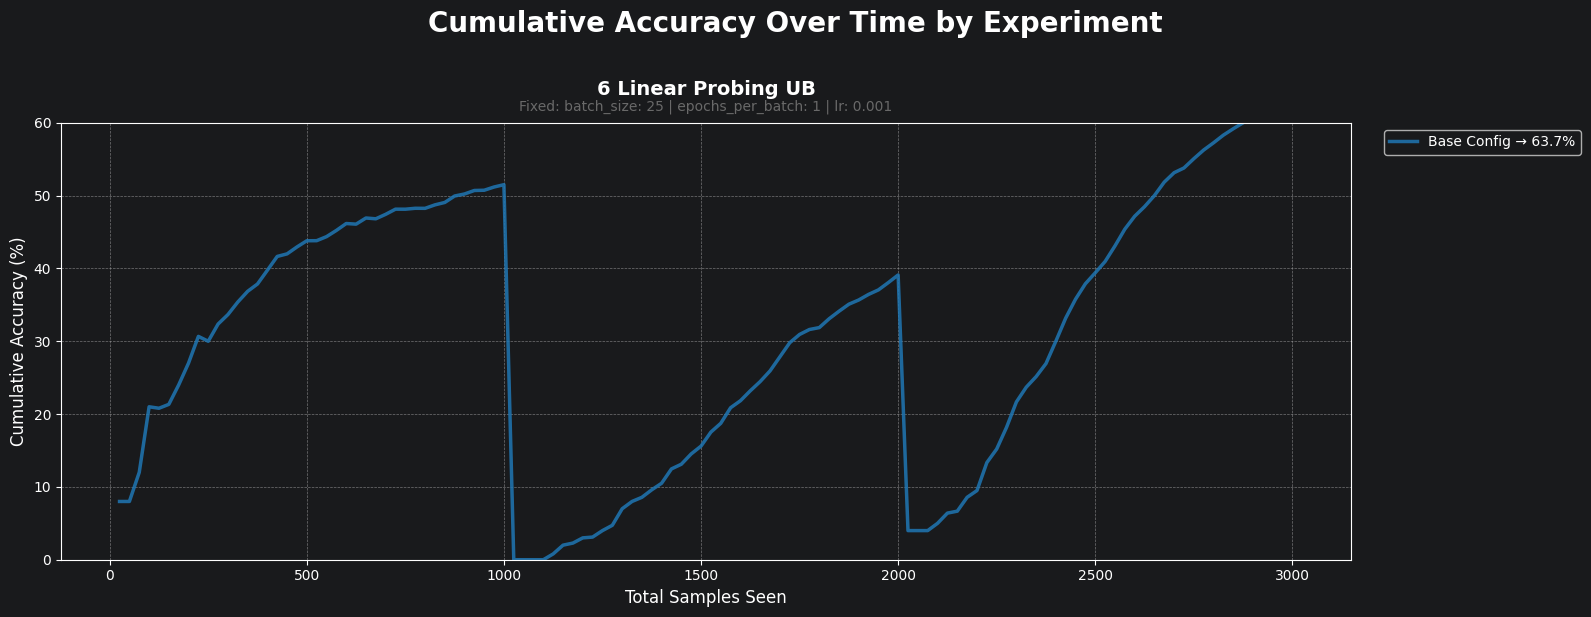


All experiments completed successfully!

Generating Distillation Comparisons...


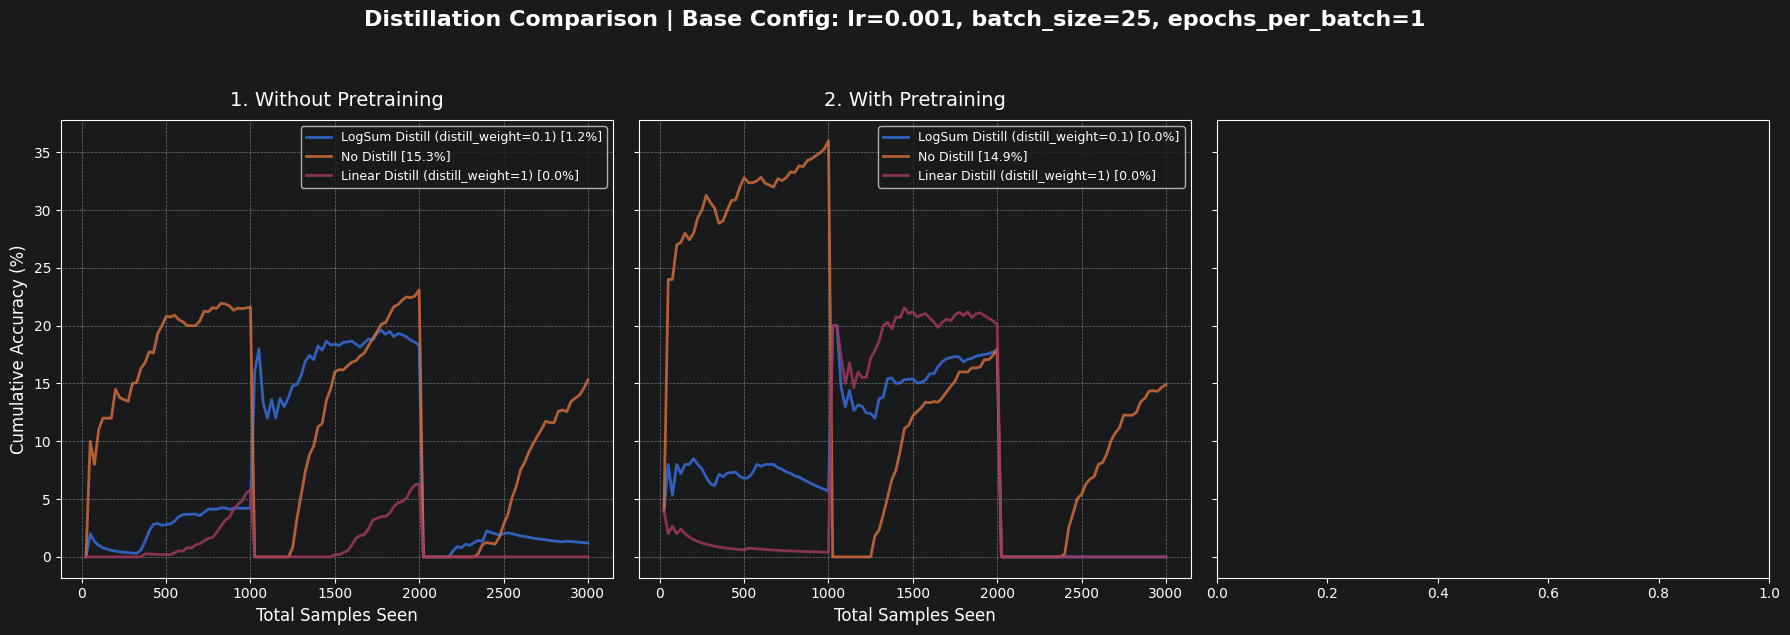

In [6]:
from GridSearch import GridSearch

gridSearch = GridSearch()
gridSearch.run_grid_search(df_stream, embedding_dim_base, pipeline, preprocessImagenet, preprocessFMOW,get_input)